<a href="https://colab.research.google.com/github/hurtadavid/Personal-Finance-and-TFSA-Portfolio-Modelling/blob/main/Personal_Finance_%26_Investment_Modelling_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Personalized TFSA Growth Calculator & Projections

In [ ]:
import pandas as pd
starting_portfolio = 23550
annual_contribution = 7000
annual_return = 0.07
years = 10

year_list = []
annual_contributions_list= []
total_contributions_list = []
portfolio_values = []
investment_gains_list = []

# Initialize portfolio with the starting value
portfolio = starting_portfolio
total_contributions = starting_portfolio

for year in range(1, years + 1):
  portfolio = portfolio * (1 + annual_return)
  portfolio = portfolio + annual_contribution

  total_contributions = starting_portfolio + (annual_contribution * year)
  investment_gains = portfolio - total_contributions

  year_list.append(year)
  annual_contributions_list.append(annual_contribution)
  total_contributions_list.append(total_contributions)
  portfolio_values.append(round(portfolio,2))
  investment_gains_list.append(round(investment_gains,2))

tfsa_table = pd.DataFrame({'Year': year_list, 'Annual Contribution': annual_contributions_list, 'Total Contributions': total_contributions_list, 'Portfolio Value': portfolio_values, 'Investment Gains': investment_gains_list})

formatted_table = tfsa_table.copy()
formatted_table['Annual Contribution'] = formatted_table['Annual Contribution'].apply(lambda x: f"${x:,.2f}")
formatted_table['Total Contributions'] = formatted_table['Total Contributions'].apply(lambda x: f"${x:,.2f}")
formatted_table['Portfolio Value'] = formatted_table['Portfolio Value'].apply(lambda x: f"${x:,.2f}")
formatted_table['Investment Gains'] = formatted_table['Investment Gains'].apply(lambda x: f"${x:,.2f}")

display (formatted_table)

final_portfolio_value = portfolio_values[-1]
final_total_contributions = total_contributions_list[-1]
final_investment_gains = investment_gains_list[-1]

print ('After', years, 'years:')
print (f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print (f"Final Total Contributions: ${final_total_contributions:,.2f}")
print (f"Final Investment Gains: ${final_investment_gains:,.2f}")

,Year,Annual Contribution,Total Contributions,Portfolio Value,Investment Gains
0,1,"$7,000.00","$30,550.00","$32,198.50","$1,648.50"
1,2,"$7,000.00","$37,550.00","$41,452.40","$3,902.40"
2,3,"$7,000.00","$44,550.00","$51,354.06","$6,804.06"
3,4,"$7,000.00","$51,550.00","$61,948.85","$10,398.85"
4,5,"$7,000.00","$58,550.00","$73,285.27","$14,735.27"
5,6,"$7,000.00","$65,550.00","$85,415.23","$19,865.23"
6,7,"$7,000.00","$72,550.00","$98,394.30","$25,844.30"
7,8,"$7,000.00","$79,550.00","$112,281.90","$32,731.90"
8,9,"$7,000.00","$86,550.00","$127,141.64","$40,591.64"
9,10,"$7,000.00","$93,550.00","$143,041.55","$49,491.55"


After 10 years:
Final Portfolio Value: $143,041.55
Final Total Contributions: $93,550.00
Final Investment Gains: $49,491.55


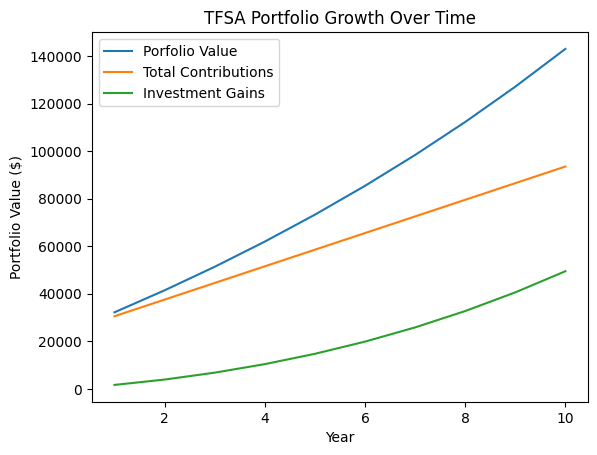

In [ ]:
import matplotlib.pyplot as plt

plt.plot(tfsa_table['Year'], tfsa_table['Portfolio Value'], label='Porfolio Value')
plt.plot(tfsa_table['Year'], tfsa_table['Total Contributions'], label='Total Contributions')
plt.plot(tfsa_table['Year'], tfsa_table['Investment Gains'], label='Investment Gains')

plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.title('TFSA Portfolio Growth Over Time')
plt.legend()
plt.show()

In [ ]:
return_scenarios = {"Conservative": 0.05, "Base Case": 0.07, "Optimistic": 0.10}

scenario_names = []
return_rates = []
final_values = []
total_contributions_values = []
investment_gains_values = []

for scenario_name, annual_return in return_scenarios.items():
  portfolio = starting_portfolio

  for year in range (1, years + 1):
    portfolio = portfolio * (1 + annual_return)
    portfolio = portfolio + annual_contribution

  total_contributions = starting_portfolio + (annual_contribution * year)
  investment_gains = portfolio - total_contributions

  scenario_names.append(scenario_name)
  return_rates.append(annual_return * 100)
  final_values.append(portfolio)
  total_contributions_values.append(total_contributions)
  investment_gains_values.append(investment_gains)

scenario_table = pd.DataFrame ({ "Scenario": scenario_names, "Annual Return": return_rates, "Final Portfolio Value": final_values, "Total Contributions": total_contributions_values, "Investment Gains": investment_gains_values})

formatted_scenario_table = scenario_table.copy()

formatted_scenario_table["Final Portfolio Value"] = formatted_scenario_table["Final Portfolio Value"].apply(lambda x: f"${x:,.2f}")
formatted_scenario_table["Total Contributions"] = formatted_scenario_table["Total Contributions"].apply(lambda x: f"${x:,.2f}")
formatted_scenario_table["Investment Gains"] = formatted_scenario_table["Investment Gains"].apply(lambda x: f"${x:,.2f}")
formatted_scenario_table["Annual Return"] = formatted_scenario_table["Annual Return"].apply(lambda x: f"{x:.0f}%")

display(formatted_scenario_table)

,Scenario,Annual Return,Final Portfolio Value,Total Contributions,Investment Gains
0,Conservative,5%,"$126,405.72","$93,550.00","$32,855.72"
1,Base Case,7%,"$143,041.55","$93,550.00","$49,491.55"
2,Optimistic,10%,"$172,644.61","$93,550.00","$79,094.61"


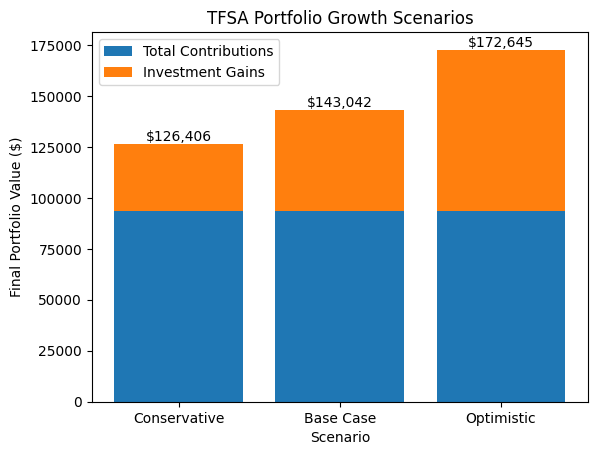

In [ ]:
import matplotlib.pyplot as plt

plt.bar(scenario_table["Scenario"], scenario_table["Total Contributions"], label = "Total Contributions")
plt.bar(scenario_table["Scenario"], scenario_table["Investment Gains"], bottom = scenario_table["Total Contributions"], label = "Investment Gains")

for i in range(len(scenario_table)):
  final_value = scenario_table["Final Portfolio Value"][i]
  scenario = scenario_table["Scenario"][i]

  plt.text(i, final_value, f"${final_value:,.0f}", ha = "center", va = "bottom")



plt.xlabel("Scenario")
plt.ylabel("Final Portfolio Value ($)")
plt.title("TFSA Portfolio Growth Scenarios")
plt.legend()
plt.show()

In [ ]:
def project_tfsa_growth(starting_portfolio, annual_contribution, annual_return, years):
  portfolio = starting_portfolio

  year_list = []
  annual_contribution_list = []
  total_contribution_list = []
  portfolio_values = []
  investment_gains_list = []

  for year in range (1, years + 1):
    portfolio = portfolio * (1 + annual_return)
    portfolio = portfolio + annual_contribution

    total_contribution = starting_portfolio + (annual_contribution * year)
    investment_gains = portfolio - total_contribution

    year_list.append(year)
    annual_contribution_list.append(annual_contribution)
    total_contribution_list.append(total_contribution)
    portfolio_values.append(round(portfolio, 2))
    investment_gains_list.append(round(investment_gains, 2))

  tfsa_table = pd.DataFrame ({ "Year": year_list, "Annual Contribution": annual_contribution_list, "Total Contribution": total_contribution_list, "Portfolio Value": portfolio_values, "Investment Gains": investment_gains_list})

  return tfsa_table

def format_money_table(table):
  formatted_table = table.copy()

  money_colums = ["Annual Contribution", "Total Contribution", "Portfolio Value", "Investment Gains"]

  for column in money_colums:
    formatted_table[column] = formatted_table[column].apply(lambda x: f"${x:,.2f}")

  return formatted_table

def print_tfsa_summary(table, years):
  final_portfolio_value = table["Portfolio Value"].iloc[-1]
  final_total_contribution = table["Total Contribution"].iloc[-1]
  final_investment_gains = table["Investment Gains"].iloc[-1]

  print ("After", years, "years:")
  print (f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
  print (f"Final Total Contributions: ${final_total_contribution:,.2f}")

In [ ]:
tfsa_table = project_tfsa_growth(0, 7000, 0.07, 10)
formatted_table = format_money_table(tfsa_table)
display(formatted_table)
print_tfsa_summary(tfsa_table, 10)

,Year,Annual Contribution,Total Contribution,Portfolio Value,Investment Gains
0,1,"$7,000.00","$7,000.00","$7,000.00",$0.00
1,2,"$7,000.00","$14,000.00","$14,490.00",$490.00
2,3,"$7,000.00","$21,000.00","$22,504.30","$1,504.30"
3,4,"$7,000.00","$28,000.00","$31,079.60","$3,079.60"
4,5,"$7,000.00","$35,000.00","$40,255.17","$5,255.17"
5,6,"$7,000.00","$42,000.00","$50,073.04","$8,073.04"
6,7,"$7,000.00","$49,000.00","$60,578.15","$11,578.15"
7,8,"$7,000.00","$56,000.00","$71,818.62","$15,818.62"
8,9,"$7,000.00","$63,000.00","$83,845.92","$20,845.92"
9,10,"$7,000.00","$70,000.00","$96,715.14","$26,715.14"


After 10 years:
Final Portfolio Value: $96,715.14
Final Total Contributions: $70,000.00


In [ ]:
tfsa_5_percent = project_tfsa_growth(0, 7000, 0.05, 10)
tfsa_10_percent = project_tfsa_growth(0, 7000, 0.10, 10)

formatted_tfsa_5_percent = format_money_table(tfsa_5_percent)
formatted_tfsa_10_percent = format_money_table(tfsa_10_percent)

display (formatted_tfsa_5_percent)
display (formatted_tfsa_10_percent)

,Year,Annual Contribution,Total Contribution,Portfolio Value,Investment Gains
0,1,"$7,000.00","$7,000.00","$7,000.00",$0.00
1,2,"$7,000.00","$14,000.00","$14,350.00",$350.00
2,3,"$7,000.00","$21,000.00","$22,067.50","$1,067.50"
3,4,"$7,000.00","$28,000.00","$30,170.88","$2,170.88"
4,5,"$7,000.00","$35,000.00","$38,679.42","$3,679.42"
5,6,"$7,000.00","$42,000.00","$47,613.39","$5,613.39"
6,7,"$7,000.00","$49,000.00","$56,994.06","$7,994.06"
7,8,"$7,000.00","$56,000.00","$66,843.76","$10,843.76"
8,9,"$7,000.00","$63,000.00","$77,185.95","$14,185.95"
9,10,"$7,000.00","$70,000.00","$88,045.25","$18,045.25"


,Year,Annual Contribution,Total Contribution,Portfolio Value,Investment Gains
0,1,"$7,000.00","$7,000.00","$7,000.00",$0.00
1,2,"$7,000.00","$14,000.00","$14,700.00",$700.00
2,3,"$7,000.00","$21,000.00","$23,170.00","$2,170.00"
3,4,"$7,000.00","$28,000.00","$32,487.00","$4,487.00"
4,5,"$7,000.00","$35,000.00","$42,735.70","$7,735.70"
5,6,"$7,000.00","$42,000.00","$54,009.27","$12,009.27"
6,7,"$7,000.00","$49,000.00","$66,410.20","$17,410.20"
7,8,"$7,000.00","$56,000.00","$80,051.22","$24,051.22"
8,9,"$7,000.00","$63,000.00","$95,056.34","$32,056.34"
9,10,"$7,000.00","$70,000.00","$111,561.97","$41,561.97"
